# Лабораторная работа №1

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, \
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, confusion_matrix, roc_curve, \
    classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier

from IPython.display import display

## 1. Разведочный анализ данных (EDA)

In [21]:
df = pd.read_csv('student_lifestyle_100k.csv')

display(df.head())
df.info()

print("\nОписание данных:")
display(df.describe().round(2))

print('Размер датасета:', df.shape)
print('Дубликатов:', int(df.duplicated().sum()))
print('Пропусков:', int(df.isna().sum().sum()))

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB

Описание данных:


,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.00,100000.00,100000.00,100000.0,100000.00,100000.00,100000.00,100000.00
mean,51000.50,21.01,2.90,7.0,4.51,3.50,74.35,4.13
std,28867.66,2.00,0.53,1.5,1.98,1.49,43.37,1.42
min,1001.00,18.00,1.56,3.0,0.00,0.00,0.00,2.00
25%,26000.75,19.00,2.45,6.0,3.20,2.50,37.00,3.00
50%,51000.50,21.00,2.90,7.0,4.50,3.50,74.00,4.00
75%,76000.25,23.00,3.35,8.0,5.80,4.50,112.00,5.00
max,101000.00,24.00,4.00,12.0,12.80,10.00,149.00,10.00


Размер датасета: (100000, 11)
Дубликатов: 0
Пропусков: 0


### Качество данных
Датасет чистый пропусков и дубликатов нет

### Очистка и приведение признаков
Удаляем `Student_ID`
Переводим `Physical_Activity` в часы
Оставляем записи где суммарная занятость не выше 24 часов

In [22]:
df = df.drop(columns="Student_ID")
df["Physical_Activity_Hours"] = df["Physical_Activity"] / 60
df = df.drop(columns=["Physical_Activity"])
daily_time_hours = df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours'] + (
        df['Physical_Activity_Hours'] / 7)
df = df[daily_time_hours <= 24].copy()
display(df.shape)

(99891, 10)

### Визуализация распределений

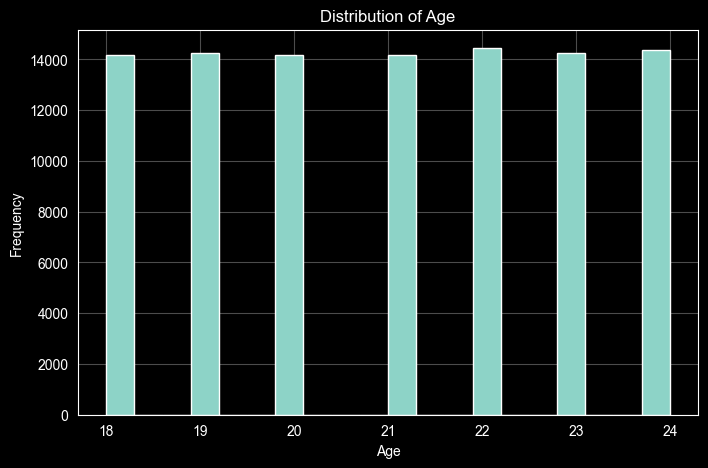

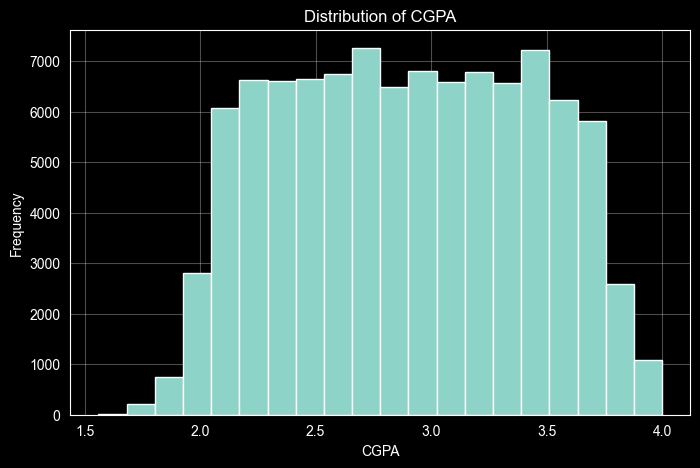

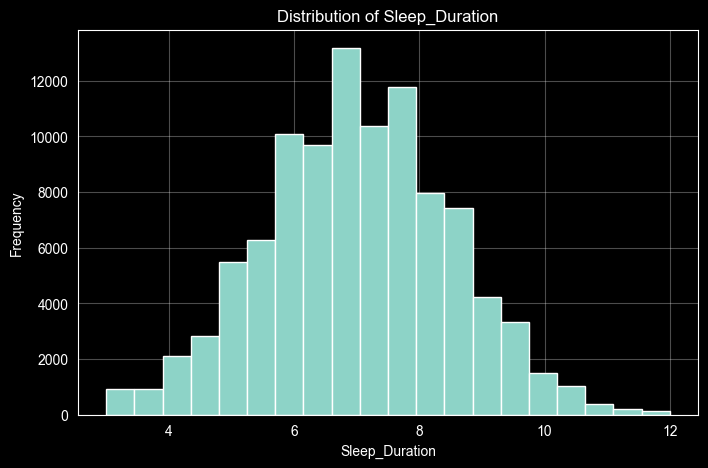

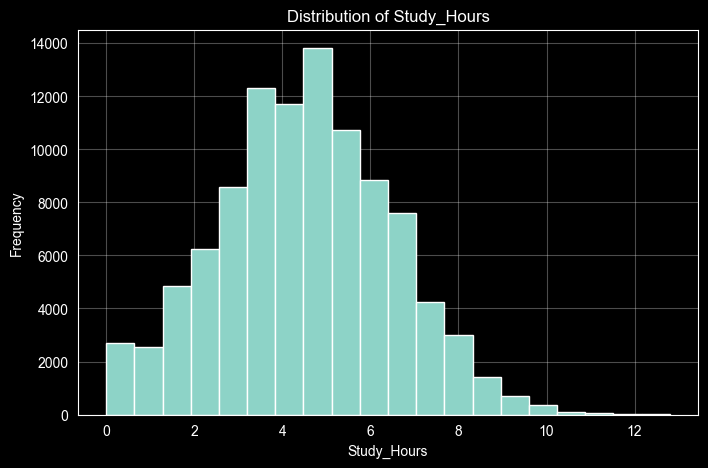

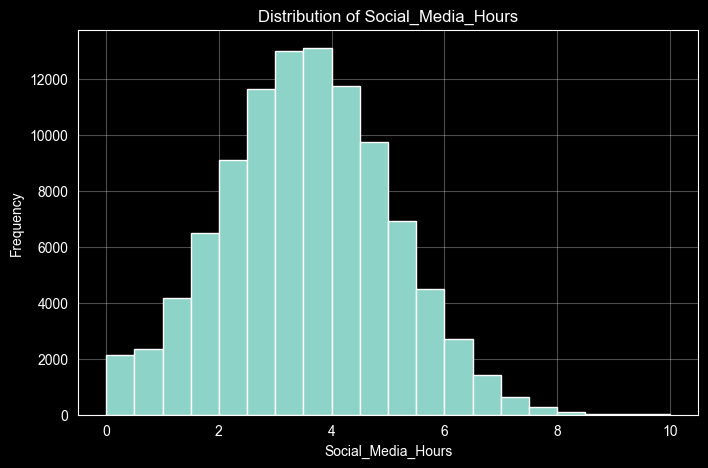

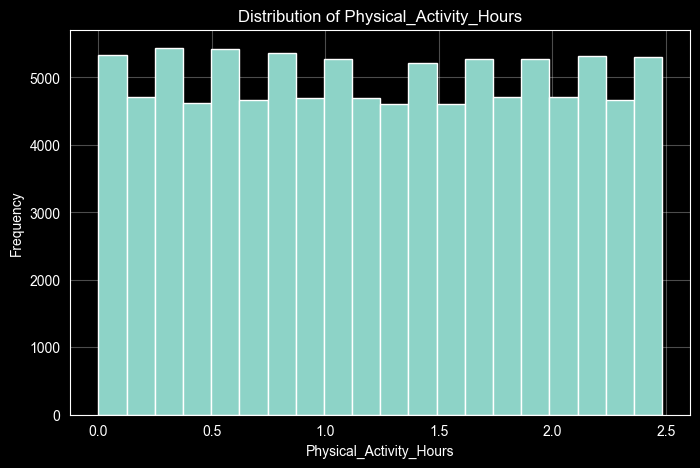

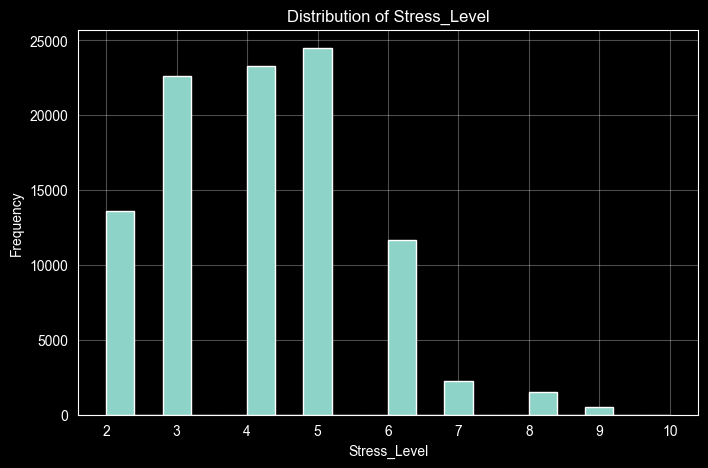

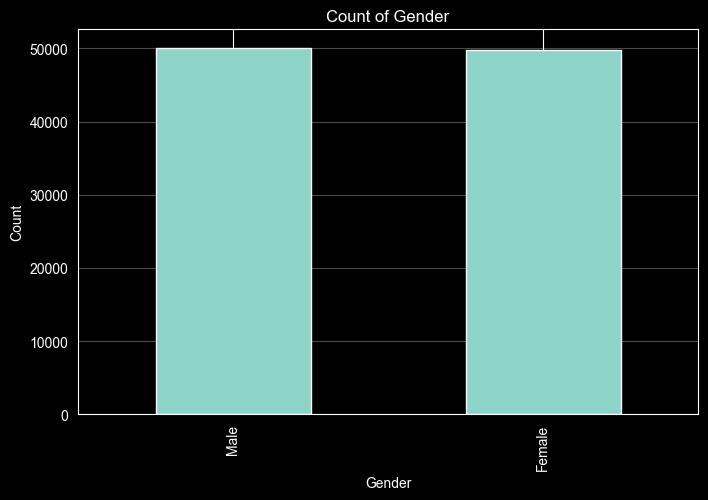

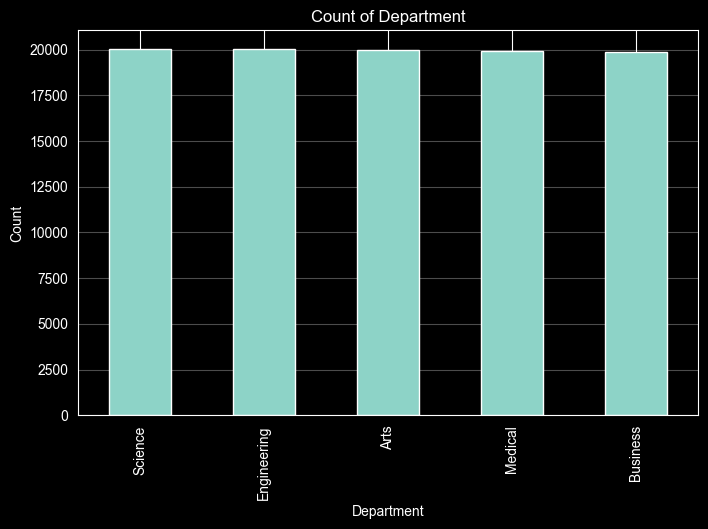

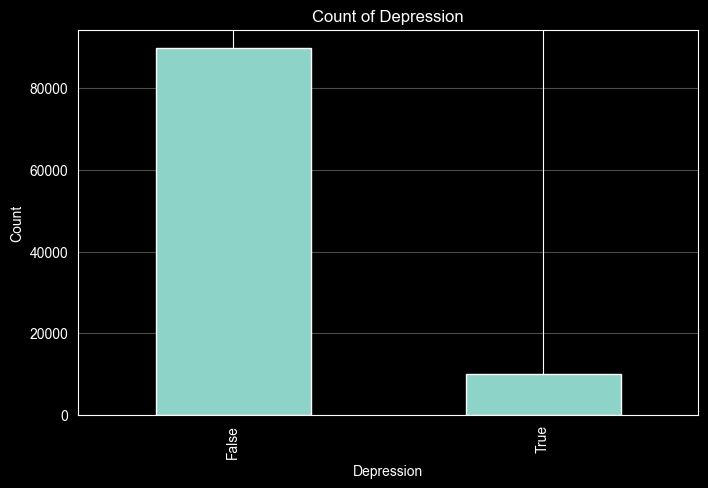

In [23]:
numeric_cols = [
    "Age",
    "CGPA",
    "Sleep_Duration",
    "Study_Hours",
    "Social_Media_Hours",
    "Physical_Activity_Hours",
    "Stress_Level"
]

categorical_cols = [
    "Gender",
    "Department",
    "Depression"
]


def visual_graf(df):
    for col in numeric_cols:
        plt.figure(figsize=(8, 5))
        plt.hist(df[col], bins=20)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)
        plt.show()

    for col in categorical_cols:
        plt.figure(figsize=(8, 5))
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Count of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.grid(True, axis="y", alpha=0.3)
        plt.show()


visual_graf(df)


### Корреляционный анализ признаков

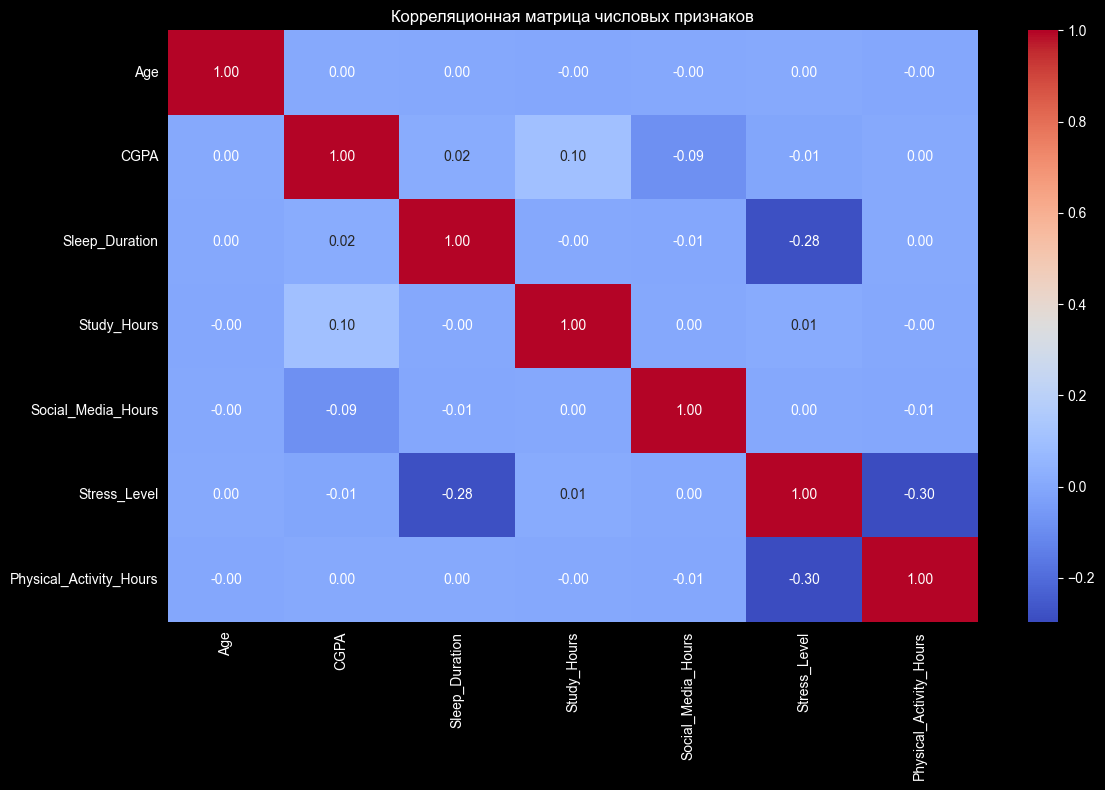

In [24]:
def correlation(df):
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Корреляционная матрица числовых признаков")
    plt.tight_layout()
    plt.show()


correlation(df)

Сильных линейных связей мало итог модели зависит от комбинации признаков

## 2. Feature Engineering и предобработка данных

### Подготовка выборок и новых признаков
Делим данные 50 30 20
Убираем выбросы только в train
Добавляем производные признаки

In [25]:
df["Study_Social_Rat"] = df["Study_Hours"] / (df["Social_Media_Hours"] + 1)
df["Total_Screen_Time"] = df["Study_Hours"] + df["Social_Media_Hours"]
df["Stress_Study_Interaction"] = df["Stress_Level"] * df["Study_Hours"]
new_cols = ["Study_Social_Rat", "Total_Screen_Time", "Stress_Study_Interaction"]
numeric_cols = list(dict.fromkeys(numeric_cols + new_cols))

df_train, df_temp = train_test_split(
    df, test_size=0.5, random_state=52, stratify=df["Depression"]
)

df_val, df_test = train_test_split(
    df_temp, test_size=0.4, random_state=52, stratify=df_temp["Depression"]
)


def remove_outliers_iqr(df, num_cols):
    df_clean = df.copy()

    for col in num_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean


print(f"До удаления выбросов: {df_train.shape}")
df_train = remove_outliers_iqr(df_train, numeric_cols)
print(f"После удаления выбросов: {df_train.shape}")


До удаления выбросов: (49945, 13)
После удаления выбросов: (45852, 13)


### Балансировка классов

До балансировки: (45852, 13), 9.87%
После балансировки: (82652, 13), 50.00%


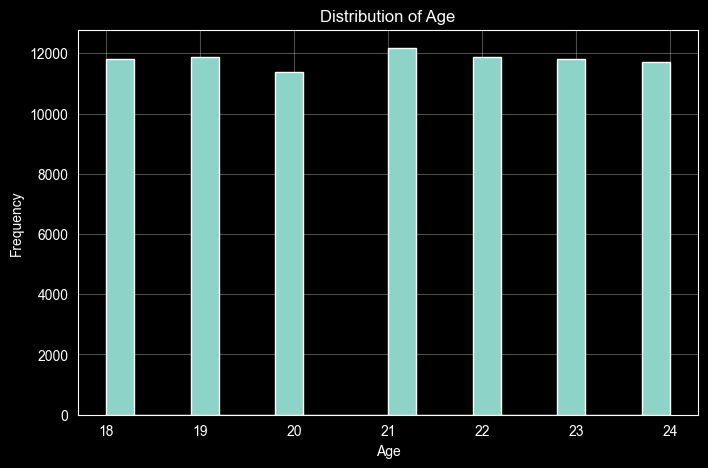

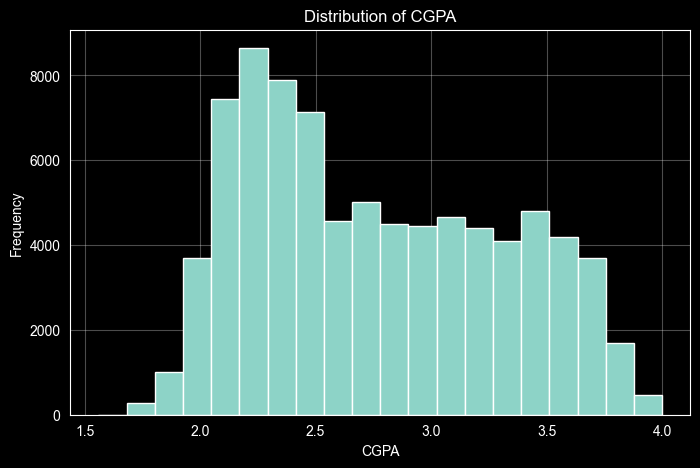

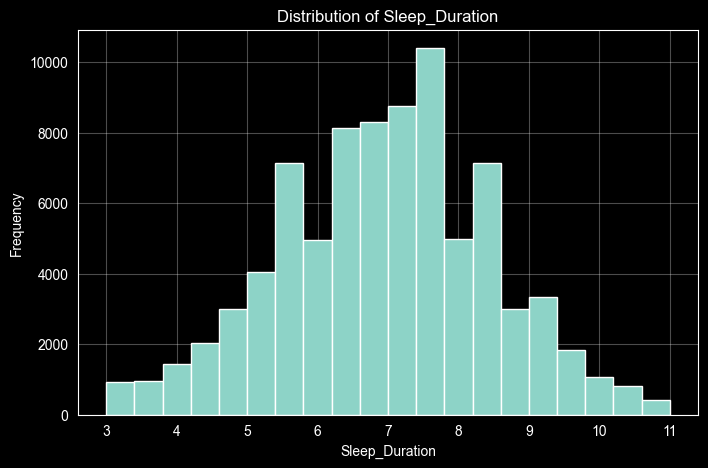

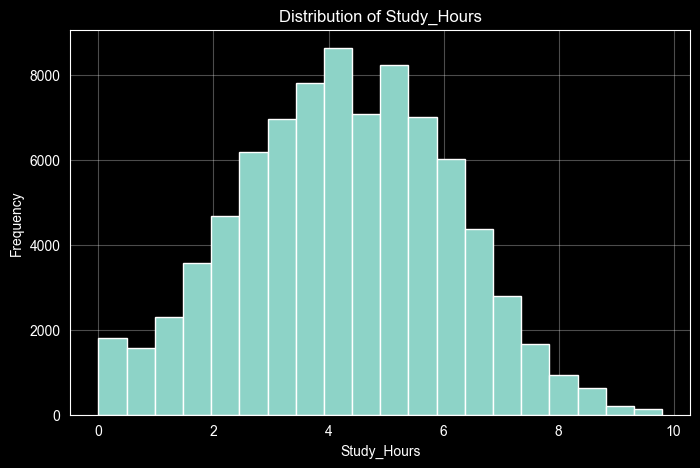

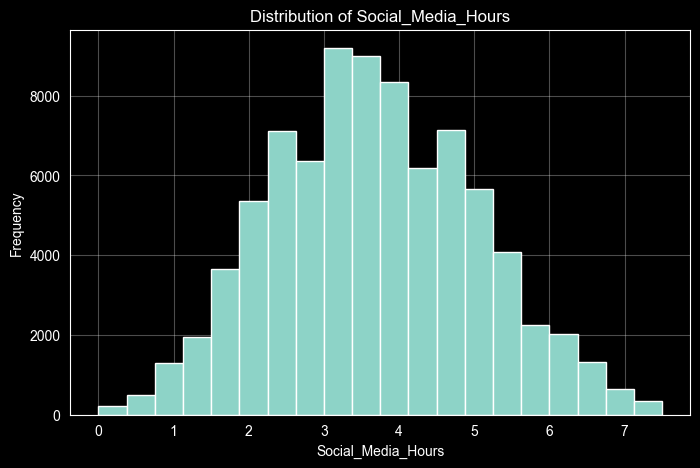

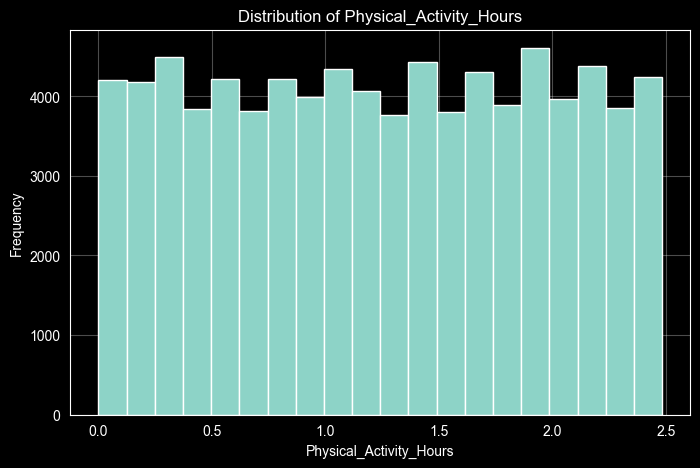

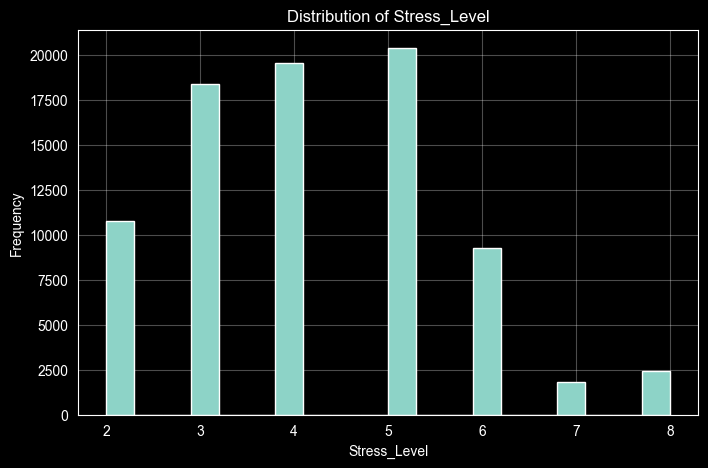

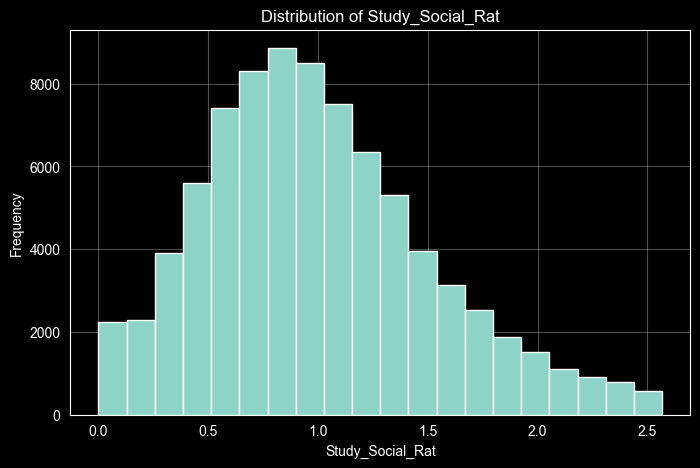

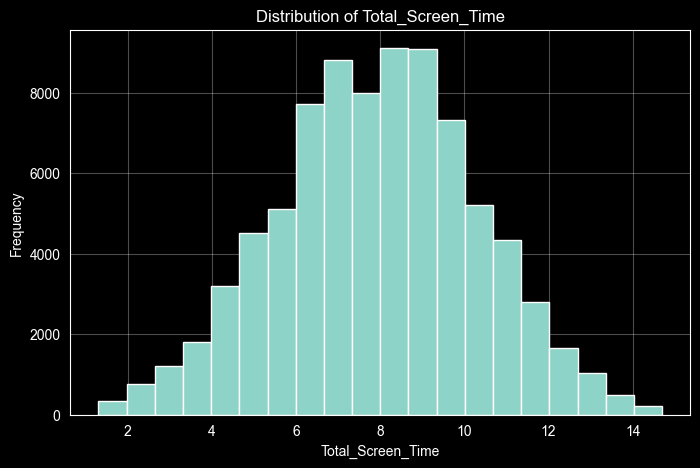

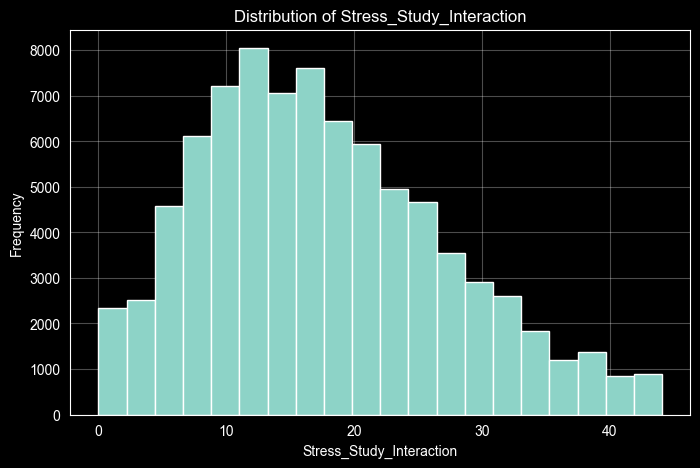

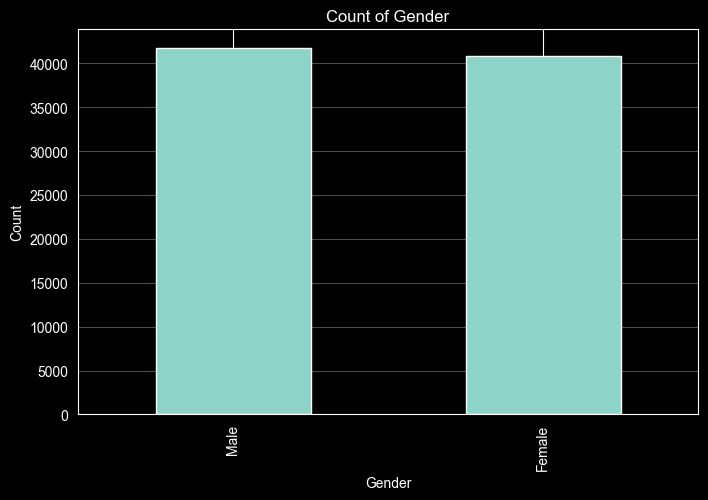

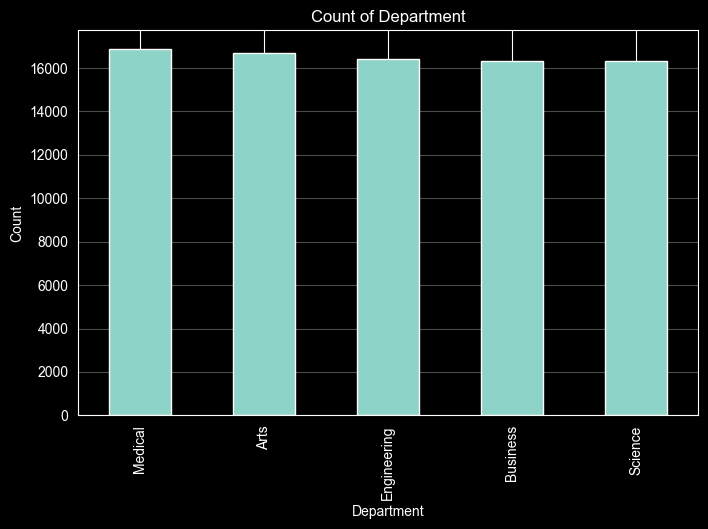

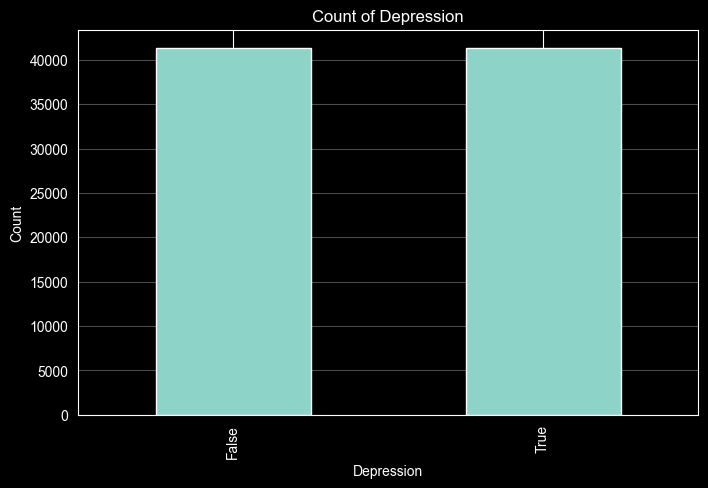

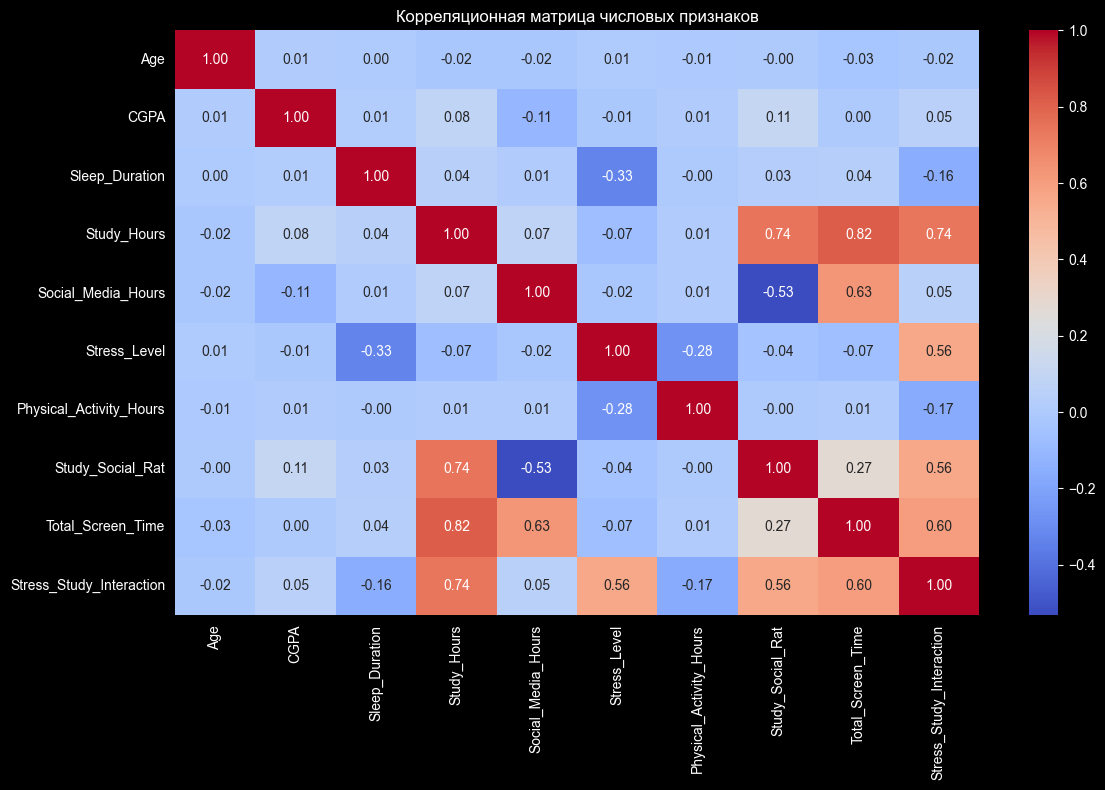

In [26]:
df_train_without_balance = df_train.copy()

print(
    f"До балансировки: {df_train.shape}, "
    f"{len(df_train[df_train['Depression'] == True]) / len(df_train):.2%}"
)

df_1 = df_train[df_train["Depression"] == True]
df_2 = df_train[df_train["Depression"] == False]

df_resample = resample(df_1, replace=True, n_samples=len(df_2), random_state=52)

df_train = pd.concat([df_2, df_resample], axis=0)
df_train = df_train.sample(frac=1, random_state=52).reset_index(drop=True)

print(
    f"После балансировки: {df_train.shape}, "f"{len(df_train[df_train['Depression'] == True]) / len(df_train):.2%}")

visual_graf(df_train)
correlation(df_train)

### Масштабирование и кодирование признаков

In [27]:
for d in [df_train_without_balance, df_train, df_val, df_test]:
    d['Depression'] = d['Depression'].astype(int)


def prepare(df_train, df_val, df_test, target_col):
    y_train = df_train[target_col]
    y_val = df_val[target_col]
    y_test = df_test[target_col]

    X_train_raw = df_train.drop(columns=[target_col])
    X_val_raw = df_val.drop(columns=[target_col])
    X_test_raw = df_test.drop(columns=[target_col])

    num_cols = X_train_raw.select_dtypes(include='number').columns.tolist()
    cat_cols = X_train_raw.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ])

    X_train = preprocessor.fit_transform(X_train_raw)
    X_val = preprocessor.transform(X_val_raw)
    X_test = preprocessor.transform(X_test_raw)

    features = preprocessor.get_feature_names_out()

    return X_train, X_val, X_test, y_train, y_val, y_test, features, preprocessor

После предобработки данные стали более однородными: уменьшено влияние выбросов и устранены пропуски, что делает обучение моделей более стабильным и предсказуемым

## Обучение моделей

In [28]:
X_train_reg, X_val_reg, X_test_reg, y_train_reg, y_val_reg, y_test_reg, features_reg, preprocessor_reg = \
    prepare(df_train_without_balance, df_val, df_test, 'CGPA')

X_train_clf, X_val_clf, X_test_clf, y_train_clf, y_val_clf, y_test_clf, features_clf, preprocessor_clf = \
    prepare(df_train, df_val, df_test, 'Depression')

### Линейная регрессия для прогноза `CGPA`

Train:
MAE  = 0.4409
RMSE = 0.5154
R²   = 0.0512

Validation:
MAE  = 0.4497
RMSE = 0.5265
R²   = 0.0288

Test:
MAE  = 0.4469
RMSE = 0.5239
R²   = 0.0297



,Actual_CGPA,Predicted_CGPA
0,2.86,2.784910
1,2.70,2.923852
2,4.00,3.006513
3,2.36,2.950399
4,3.29,2.987477
5,3.32,2.392125
6,2.87,2.963271
7,3.08,2.961924
8,2.76,2.980966
9,2.45,2.979801


,Feature,Coefficient
2,num__Study_Hours,0.123012
8,num__Total_Screen_Time,0.027954
4,num__Stress_Level,0.021410
6,num__Physical_Activity_Hours,0.002930
1,num__Sleep_Duration,0.001727
0,num__Age,0.000039
11,cat__Department_Business,-0.007250
14,cat__Department_Science,-0.010130
10,cat__Gender_Male,-0.010635
12,cat__Department_Engineering,-0.011256


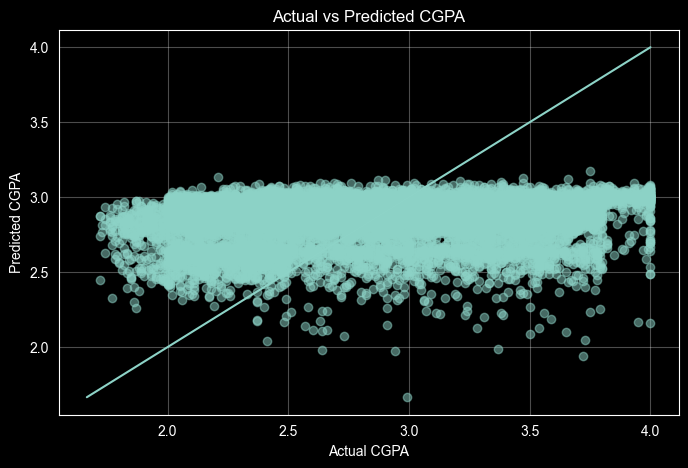

In [35]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

y_train_pred = lin_reg.predict(X_train_reg)
y_val_pred = lin_reg.predict(X_val_reg)
y_test_pred = lin_reg.predict(X_test_reg)


def regression_metrics(y_true, y_pred, name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name}:")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")
    print()


regression_metrics(y_train_reg, y_train_pred, "Train")
regression_metrics(y_val_reg, y_val_pred, "Validation")
regression_metrics(y_test_reg, y_test_pred, "Test")

results_reg = pd.DataFrame({
    "Actual_CGPA": y_test_reg.values,
    "Predicted_CGPA": y_test_pred
})

display(results_reg.head(10))

coef_df = pd.DataFrame({
    "Feature": features_reg,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

display(coef_df)

plt.figure(figsize=(8, 5))
plt.scatter(y_test_reg, y_test_pred, alpha=0.5)
plt.xlabel("Actual CGPA")
plt.ylabel("Predicted CGPA")
plt.title("Actual vs Predicted CGPA")

min_val = min(y_test_reg.min(), y_test_pred.min())
max_val = max(y_test_reg.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.grid(True, alpha=0.3)
plt.show()

### Логистическая регрессия для прогноза `Depression`

In [30]:
def evaluate_clf(model, X, y, name="Dataset"):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_proba)

    print(f"{name}:")
    print(f"Accuracy = {acc:.4f}")
    print(f"F1       = {f1:.4f}")
    print(f"ROC-AUC  = {roc_auc:.4f}")
    print()

    return {
        "dataset": name,
        "accuracy": acc,
        "f1": f1,
        "roc_auc": roc_auc
    }

### Подбор learning rate и числа эпох

In [31]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
epochs_list = [10, 100, 1000]

results = []

for lr in learning_rates:
    for epochs in epochs_list:
        model = SGDClassifier(loss="log_loss", learning_rate="constant", tol=lr, max_iter=epochs, random_state=52,
                              class_weight=None)

        model.fit(X_train_clf, y_train_clf)

        y_val_pred = model.predict(X_val_clf)
        y_val_proba = model.predict_proba(X_val_clf)[:, 1]

        acc = accuracy_score(y_val_clf, y_val_pred)
        f1 = f1_score(y_val_clf, y_val_pred)
        roc_auc = roc_auc_score(y_val_clf, y_val_proba)

        results.append({
            "learning_rate": lr,
            "epochs": epochs,
            "val_accuracy": acc,
            "val_f1": f1,
            "val_roc_auc": roc_auc
        })

results_df = pd.DataFrame(results).sort_values(by="val_roc_auc", ascending=False)
display(results_df)

best_row = results_df.iloc[0]
best_lr = best_row["learning_rate"]
best_epochs = int(best_row["epochs"])

print("Лучшие параметры:")
print(f"learning_rate = {best_lr}")
print(f"epochs = {best_epochs}")

,learning_rate,epochs,val_accuracy,val_f1,val_roc_auc
0,0.0001,10,0.566223,0.250303,0.676142
1,0.0001,100,0.566223,0.250303,0.676142
2,0.0001,1000,0.566223,0.250303,0.676142
3,0.0010,10,0.633764,0.264952,0.674852
4,0.0010,100,0.633764,0.264952,0.674852
5,0.0010,1000,0.633764,0.264952,0.674852
6,0.0100,10,0.633764,0.264952,0.674852
7,0.0100,100,0.633764,0.264952,0.674852
8,0.0100,1000,0.633764,0.264952,0.674852
9,0.1000,10,0.633764,0.264952,0.674852


Лучшие параметры:
learning_rate = 0.0001
epochs = 10


### Финальная модель с лучшими параметрами

Train:
Accuracy = 0.6520
F1       = 0.6646
ROC-AUC  = 0.6878

Validation:
Accuracy = 0.6254
F1       = 0.2662
ROC-AUC  = 0.6828

Test:
Accuracy = 0.6256
F1       = 0.2633
ROC-AUC  = 0.6773



,Feature,Coefficient
5,num__Stress_Level,0.090377
9,num__Stress_Study_Interaction,0.017220
4,num__Social_Media_Hours,0.014317
13,cat__Department_Medical,0.009714
6,num__Physical_Activity_Hours,0.000323
10,cat__Gender_Male,-0.000829
11,cat__Department_Business,-0.002954
8,num__Total_Screen_Time,-0.003546
12,cat__Department_Engineering,-0.006083
0,num__Age,-0.008962


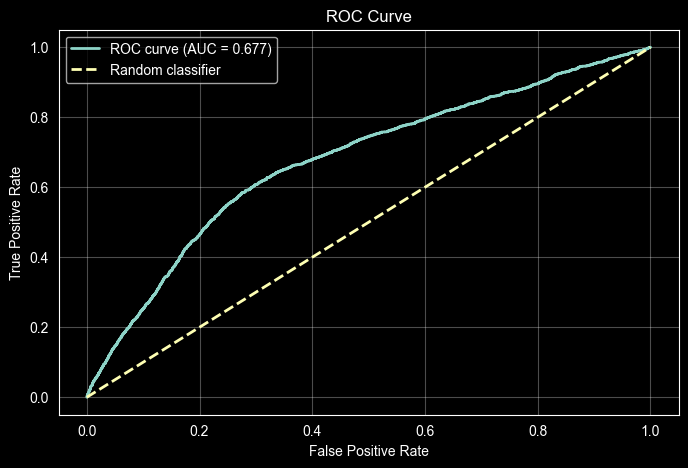

In [32]:
best_model = LogisticRegression(C=float(best_lr), max_iter=int(best_epochs), solver='lbfgs', random_state=52)

best_model.fit(X_train_clf, y_train_clf)

train_metrics = evaluate_clf(best_model, X_train_clf, y_train_clf, "Train")
val_metrics = evaluate_clf(best_model, X_val_clf, y_val_clf, "Validation")
test_metrics = evaluate_clf(best_model, X_test_clf, y_test_clf, "Test")

y_test_pred = best_model.predict(X_test_clf)

coef_df = pd.DataFrame({
    "Feature": X_train_clf.columns if hasattr(X_train_clf, "columns") else features_clf,
    "Coefficient": best_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

display(coef_df)

y_test_proba = best_model.predict_proba(X_test_clf)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_clf, y_test_proba)
roc_auc = roc_auc_score(y_test_clf, y_test_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Выводы

Обе модели не показали признаков переобучения: метрики на train, validation и test находятся на сопоставимом уровне.
Была выполнена предобработка (обработка пропусков, удаление выбросов), что улучшило стабильность моделей. Для логистической регрессии применялась балансировка классов, так как без неё модель смещалась в сторону класса no depression, давая высокий precision, но низкий recall, который в данной задаче важнее.
Датасет оказался достаточно чистым, а наиболее значимым признаком в модели логистической регрессии является CGPA.
